In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt


# calculate how long time the simulation it is
start_time = time.time()
# mesh-size, contact area coefficient
mesh_min = 3
mesh_max = 5
c_contact = 1
# Each time step rotation angular, and acc during lag, 1 is full acc, 0 is no acc.
angular_r = 224
v_vehicle = 160
c_acc = 1

def vehicle_initial(angular_r, v_vehicle, c_contact, c_acc):
    import numpy as np
    # v_ini  =  raad/ss
    v_ini = v_vehicle/3.6   /   (920/2/1000) 
    # D_wheel = 920 mm, v = D_wheel /2 /1000 * v_ini *3.6   # km/h
    # Start time, Final time  
    t = 0
    t_brake = 49
    t_lag1 = 6
    t_lag2 = 8
    # rubbing element radius, Contact area 
    r_rub = 18.8
    S_rub_circle = r_rub**2 * c_contact
    S_total = S_rub_circle * np.pi * 18  #mm2
    # initial and brake pad temperature
    Ti = 60
    Tm = 60
    # density (kg.m^-3), capacity (J/Kg.K), conductivity (W/m.K)
    t_u = 1e3 # m to mm
    rho = 7850 /(t_u**3)
    c = 462
    k = 48 / t_u
    # mu, P_brake,  r_disc , heat_distribution  
    mu = 0.376
    P_initial = 274000
    r_disc = 0.25
    heat_distribution = 0.88
    # calculate total num_steps
    if c_acc == 1:  # constant acc for the whole process
        acc = v_ini/t_brake
        # end velocity, km/h
        v_lag_end1 = (v_ini - (acc *t_lag1) )  
        v_lag_end2 = (v_ini - (acc *(t_lag1+t_lag2) ) )
        # angular speed, rad/s
        angular_r_rad = angular_r / 180 *np.pi  
        # lag time for period 1 and 2
        dt_lag1 = angular_r_rad  /  ( ( v_ini + v_lag_end1  ) /2 )
        dt_lag2 = angular_r_rad  /  ( ( v_lag_end1 + v_lag_end2  ) /2 )
        # lag steps for period 1 and 2
        n_lag1 = round (t_lag1 / dt_lag1) + 1 
        n_lag2 = round (t_lag2 / dt_lag2) + 1
        # every second, the rotation angular divide average speed, then know the average dt.
        dt_a_lag2 = angular_r_rad  /  ( v_lag_end2 /2 )     
        n_a_lag =  round ( (t_brake - t_lag1 - t_lag2) / dt_a_lag2 )+ 1     
        num_steps = n_lag1 + n_lag2 + n_a_lag
        
        dt = []
        v_angular = [v_ini]
        for i in range(num_steps):
            dt.append ( angular_r_rad / v_angular[i] )
            v_angular.append (  v_ini- sum(dt) * acc )           
        P = []
        
        for i in range(num_steps):
            #if i <= n_lag1:
            if i<= ((n_lag1 + n_lag2)):
                # linear pressure increase * 10%
               P.append( P_initial/ n_lag1 * ((0.1*i) **2 )*0.4)
            #elif n_lag1 < i <= (n_lag1 + n_lag2):
                # heat lost in lag1 is added on lag2, 50%, should be 90% here
              # P.append( P_initial/ n_lag1 * ((i-n_lag1)**2* 0.01 ) ) 
            else:
                P.append( P_initial) 
            
          
    # S_or is the original brake pad rubbing area, 200 cm2. 
    S_or = 200
    S_new = S_total/100 #mm2 to cm2
    g = []
    for i in range(num_steps):
        g.append ( mu * P[i] * v_angular[i] * r_disc * heat_distribution *2 /(t_u**2)  * (S_or/S_new) )
    h = 7.75e-5
    radiation = 5.670*(10e-8)/(t_u**2)  * 0.64
    return dt,P,g,num_steps,h,radiation,v_angular,Ti,Tm,S_rub_circle,t,rho,c,k,t_brake,S_total,n_lag1,n_lag2,n_a_lag   
# calling local functions to get all parameters
( dt,P,g,num_steps,h,radiation,v_angular,Ti,Tm,S_rub_circle,t,rho,c, k, t_brake,S_total,n_lag1,n_lag2,n_a_lag) = vehicle_initial (angular_r, v_vehicle, c_contact, c_acc)




In [2]:
time_t = []
sum=0
for i in range(len(dt)):
    sum = sum +dt[i]
    time_t.append( sum)

    

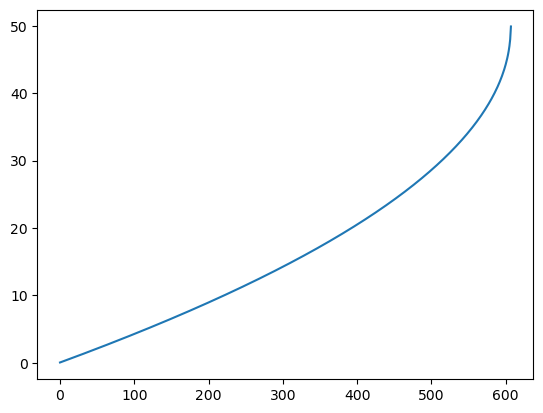

In [3]:
plt.plot(time_t)

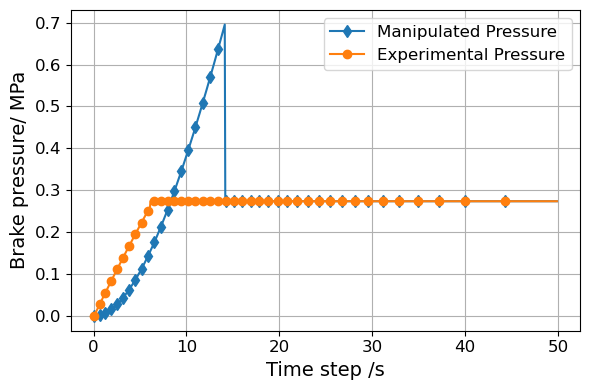

In [4]:
with open('origin_pressure.txt', 'r') as f:
   p_mpa2 = [line.strip() for line in f]
p_mpa2_n = [float(n) for n in p_mpa2]
    
del dt[-1] 
num_steps = num_steps -1

p_mpa = [ n/1000000 for n in P]

plt.figure(figsize=(6, 4))
fontsize_global = 12
plt.xticks(fontsize=fontsize_global)
plt.yticks(fontsize=fontsize_global)


plt.plot(time_t, p_mpa, label= "Manipulated Pressure",marker='d', markevery=15)
plt.plot(time_t, p_mpa2_n, label= "Experimental Pressure",marker='o', markevery=15)
plt.xlabel("Time step /s",fontsize=14)  # Label for x-axis
plt.ylabel("Brake pressure/ MPa",fontsize=14)  # Label for y-axis

plt.legend(fontsize=fontsize_global)
plt.grid(True)
plt.tight_layout()
plt.savefig('fem_pressures.pdf')

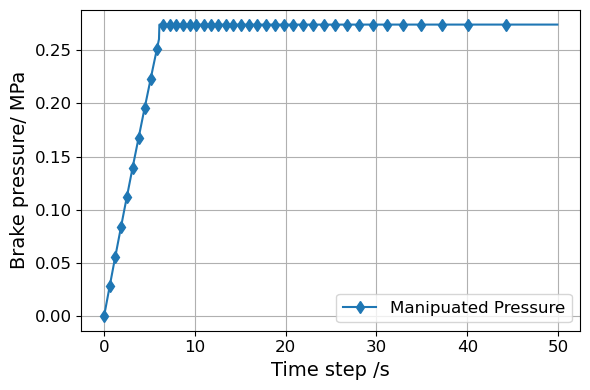

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

mesh_min = 3
mesh_max = 5
c_contact = 1
# Each time step rotation angular, and acc during lag, 1 is full acc, 0 is no acc.
angular_r = 224
v_vehicle = 160
c_acc = 1
def vehicle_initial(angular_r, v_vehicle, c_contact, c_acc):
    import numpy as np
    # v_ini  =  raad/ss
    v_ini = v_vehicle/3.6   /   (920/2/1000) 
    # D_wheel = 920 mm, v = D_wheel /2 /1000 * v_ini *3.6   # km/h
    # Start time, Final time  
    t = 0
    t_brake = 49
    t_lag1 = 6
    t_lag2 = 8
    # rubbing element radius, Contact area 
    r_rub = 18.8
    S_rub_circle = r_rub**2 * c_contact
    S_total = S_rub_circle * np.pi * 18  #mm2
    # initial and brake pad temperature
    Ti = 60
    Tm = 60
    # density (kg.m^-3), capacity (J/Kg.K), conductivity (W/m.K)
    t_u = 1e3 # m to mm
    rho = 7850 /(t_u**3)
    c = 462
    k = 48 / t_u
    # mu, P_brake,  r_disc , heat_distribution  
    mu = 0.376
    P_initial = 274000
    r_disc = 0.25
    heat_distribution = 0.88
    # calculate total num_steps
    if c_acc == 1:  # constant acc for the whole process
        acc = v_ini/t_brake
        # end velocity, km/h
        v_lag_end1 = (v_ini - (acc *t_lag1) )  
        v_lag_end2 = (v_ini - (acc *(t_lag1+t_lag2) ) )
        # angular speed, rad/s
        angular_r_rad = angular_r / 180 *np.pi  
        # lag time for period 1 and 2
        dt_lag1 = angular_r_rad  /  ( ( v_ini + v_lag_end1  ) /2 )
        dt_lag2 = angular_r_rad  /  ( ( v_lag_end1 + v_lag_end2  ) /2 )
        # lag steps for period 1 and 2
        n_lag1 = round (t_lag1 / dt_lag1) + 1 
        n_lag2 = round (t_lag2 / dt_lag2) + 1
        # every second, the rotation angular divide average speed, then know the average dt.
        dt_a_lag2 = angular_r_rad  /  ( v_lag_end2 /2 )     
        n_a_lag =  round ( (t_brake - t_lag1 - t_lag2) / dt_a_lag2 )+ 1     
        num_steps = n_lag1 + n_lag2 + n_a_lag
        
        dt = []
        v_angular = [v_ini]
        for i in range(num_steps):
            dt.append ( angular_r_rad / v_angular[i] )
            v_angular.append (  v_ini- sum(dt) * acc )           
        P = []
        
        for i in range(num_steps):
            if i <= n_lag1:
            # linear pressure increase * 10%
               P.append( P_initial/ n_lag1 * (i )*0.95)
            #elif n_lag1 < i <= (n_lag1 + n_lag2):
                # heat lost in lag1 is added on lag2, 50%, should be 90% here
             #  P.append( P_initial/ n_lag1 * ((i-n_lag1)**2* 0.01 ) ) 
            else:
                P.append( P_initial) 
            
          
    # S_or is the original brake pad rubbing area, 200 cm2. 
    S_or = 200
    S_new = S_total/100 #mm2 to cm2
    g = []
    for i in range(num_steps):
        g.append ( mu * P[i] * v_angular[i] * r_disc * heat_distribution *2 /(t_u**2)  * (S_or/S_new) )
    h = 7.75e-5
    radiation = 5.670*(10e-8)/(t_u**2)  * 0.64
    return dt,P,g,num_steps,h,radiation,v_angular,Ti,Tm,S_rub_circle,t,rho,c,k,t_brake,S_total,n_lag1,n_lag2,n_a_lag   
# calling local functions to get all parameters
( dt,P,g,num_steps,h,radiation,v_angular,Ti,Tm,S_rub_circle,t,rho,c, k, t_brake,S_total,n_lag1,n_lag2,n_a_lag) = vehicle_initial (angular_r, v_vehicle, c_contact, c_acc)



num_steps = num_steps -1

time_t = []
sum=0
for i in range(len(dt)):
    sum = sum +dt[i]
    time_t.append( sum)


p_mpa1 = [ n/1000000 for n in P]

plt.figure(figsize=(6, 4))
fontsize_global = 12
plt.xticks(fontsize=fontsize_global)
plt.yticks(fontsize=fontsize_global)


plt.plot(time_t, p_mpa1, label= "Manipuated Pressure",marker='d', markevery=15)
plt.xlabel("Time step /s",fontsize=14)  # Label for x-axis
plt.ylabel("Brake pressure/ MPa",fontsize=14)  # Label for y-axis

plt.legend(fontsize=fontsize_global)
plt.grid(True)
plt.tight_layout()
#plt.savefig('fem_pressures.pdf')



In [2]:
type(p_mpa1)

with open('origin_pressure.txt','w') as f:
    for item in p_mpa1:
        f.write(f"{item}\n")

In [3]:
with open('origin_pressure.txt', 'r') as f:
   p_mpa2 = [line.strip() for line in f]

In [4]:
type(p_mpa2)

list

In [5]:
print(p_mpa2[:5])

['0.0', '0.0018592857142857141', '0.0037185714285714283', '0.005577857142857143', '0.007437142857142857']


In [7]:
print(p_mpa[:5])

[0.0, 7.828571428571431e-06, 3.1314285714285725e-05, 7.045714285714288e-05, 0.0001252571428571429]
